In [ ]:
import pandas as pd
import gdown
import os




In [648]:
dict_plikow = {
    'towar': 'https://drive.google.com/file/d/1BnYuwCY4A7fzb5Vg36r6vpCbRhM_acDZ/view?usp=drive_link',
    'pozdok': 'https://drive.google.com/file/d/1q9x3lCAb9u0BPqbEzGJLhdkESDon33Sl/view?usp=drive_link',
    'dok':'https://drive.google.com/file/d/1ONZ1yvmTAsGq1P9FieuZvyRINUNHj1dk/view?usp=drive_link',
    'asort': 'https://drive.google.com/file/d/15vZYClznfSQDGO_qS0gPJ3J9Vo5ZKzsS/view?usp=sharing'
}



In [649]:
force_redownload = False  # ustaw True, gdy chcesz odświeżyć dane
file_path = "dane"

for key, url in dict_plikow.items():
    file_path = f"dane/{key}.parquet"
    if os.path.exists(file_path) and not force_redownload:
        print(f"Plik {file_path} już istnieje - pomijam.")
        continue
    gdown.download(url, file_path, quiet=False)

Plik dane/towar.parquet już istnieje - pomijam.
Plik dane/pozdok.parquet już istnieje - pomijam.
Plik dane/dok.parquet już istnieje - pomijam.
Plik dane/asort.parquet już istnieje - pomijam.


#  DOK

In [650]:
pozdok = pd.read_parquet('dane/pozdok.parquet', engine='pyarrow')


In [651]:
pozdok.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'TowId', 'TypPoz', 'IloscPlus',
       'IloscMinus', 'PoziomCen', 'Metoda', 'CenaDomyslna', 'CenaPrzedRab',
       'RabatProc', 'CenaPoRab', 'Wartosc', 'CenaDet', 'CenaMag', 'Stawka',
       'TypTowaru', 'IleWZgrzewce', 'StawkaDod', 'Netto', 'Podatek',
       'SledzPartii', 'UUID'],
      dtype='str')

In [652]:
pozdok = pozdok.drop(columns=['IleWZgrzewce','StawkaDod','Netto','Podatek','SledzPartii', 'UUID','Metoda','PoziomCen']).copy()

In [653]:
pozdok.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'TowId', 'TypPoz', 'IloscPlus',
       'IloscMinus', 'CenaDomyslna', 'CenaPrzedRab', 'RabatProc', 'CenaPoRab',
       'Wartosc', 'CenaDet', 'CenaMag', 'Stawka', 'TypTowaru'],
      dtype='str')

In [654]:
# asort = pd.read_csv('dane_all_product/ASORT.csv', sep=',', low_memory=False, on_bad_lines='skip', index_col=False, encoding='latin-1')
# asort = asort.to_parquet('dane_all_product/asort.parquet', index=False)
# asort = pd.read_parquet('dane_all_product/ASORT.parquet')
asort = pd.read_parquet('dane/asort.parquet')

In [655]:
asort=asort.drop(columns=['OpcjaMarzy',
'HurtRabat',
'OpcjaRabatu',
'NocNarzut',
'OpcjaNarzutu',
'CentrAsId',
'UkrytyNaPanelach',
'UkrytyNaBonowniku',
'BezAutoEtykiet',
'Param1',
'Autoryzacja'
]).copy()

In [656]:
asort.sample(10)

,AsId,Nazwa,Marza
78,163,ORZESZKI /przekąski,0.00
74,158,RYŻE /zbożowe i sypkie,0.00
146,281,04 AKCESORIA TYTONIOWE W KIOSKU,0.00
203,355,piwa 0% 23% vatu,0.00
69,153,MAKARONY /zbożowe i sypkie,0.00
108,195,KONSERWY MIĘSNE /przetwory mięsne,0.00
319,212,RYBY ŚWIEŻE WAGA,0.25
147,282,03 ART. TYTONIOW CYGARETKI KIOSK,0.00
143,278,12 PRZEMYSŁOWE KIOSK,0.00
176,324,ĆWIKŁY,0.00


## Towar

In [657]:
towar = pd.read_parquet('dane/towar.parquet')

In [658]:
towar.columns

Index(['TowId', 'AsId', 'JMId', 'KatId', 'Producent', 'ArtId', 'Nazwa',
       'Skrot', 'Kod', 'TypTowaru', 'Indeks1', 'Indeks2', 'Opis1', 'Opis2',
       'Opis3', 'Opis4', 'TermWazn', 'Marza', 'HurtRabat', 'NocNarzut',
       'OpcjaMarzy', 'OpcjaRabatu', 'OpcjaNarzutu', 'CenaEw', 'CenaDet',
       'CenaHurt', 'CenaNoc', 'CenaDod', 'CenaOtwarta', 'PoziomCen', 'PrefPLU',
       'Stawka', 'IleWZgrzewce', 'IleWCalosci', 'KodZgrzewki', 'Aktywny',
       'Waga', 'Szerokosc', 'Wysokosc', 'Glebokosc', 'CKU', 'BlokDostawcow',
       'BlokCenyZak', 'BlokCenSp', 'BlokZmian', 'Rezerwa1', 'Rezerwa2',
       'CentrTowId', 'Zmiana', 'Akcyzowy', 'SledzPartii', 'MaxCenaZak',
       'PrzeliczJM', 'NrDrukarki', 'Cena5', 'Cena6', 'ProgPromocji',
       'ZmianaIstotna', 'ZmianaTylkoCen', 'Przeznaczenie', 'ObslugaPartii',
       'UkrycNaKasie', 'KodCN', 'MinCenaSp', 'SubsysKoduGlownego', 'StatusZam',
       'KodGlownyCentralny', 'NowoscOd', 'NowoscPrzez',
       'WysylacNaSklepInternetowy', 'GrupaGTU', 'Kr

In [659]:
towar=towar.drop(columns=['JMId',
'KatId',
'Producent',
'ArtId',
'Skrot',
'TypTowaru',
'Indeks1',
'Indeks2',
'Opis1',
'Opis2',
'Opis3',
'Opis4',
'TermWazn',
'HurtRabat',
'NocNarzut',
'OpcjaMarzy',
'OpcjaRabatu',
'OpcjaNarzutu',
'CenaNoc',
'CenaDod',
'CenaOtwarta',
'PoziomCen',
'PrefPLU',
'IleWZgrzewce',
'IleWCalosci',
'Opis4',
'TermWazn',
'HurtRabat',
'NocNarzut',
'OpcjaMarzy',
'OpcjaRabatu',
'OpcjaNarzutu',
'CenaNoc',
'CenaDod',
'CenaOtwarta',
'PoziomCen',
'PrefPLU',
'IleWZgrzewce',
'IleWCalosci',
'KodZgrzewki',
'Aktywny',
       'Waga', 'Szerokosc', 'Wysokosc', 'Glebokosc', 'CKU', 'BlokDostawcow',
       'BlokCenyZak', 'BlokCenSp', 'BlokZmian', 'Rezerwa1', 'Rezerwa2',
       'CentrTowId', 'Zmiana', 'Akcyzowy', 'SledzPartii', 'MaxCenaZak',
       'PrzeliczJM', 'NrDrukarki', 'Cena5', 'Cena6', 'ProgPromocji',
       'ZmianaIstotna', 'ZmianaTylkoCen', 'Przeznaczenie', 'ObslugaPartii',
       'UkrycNaKasie', 'KodCN', 'MinCenaSp', 'SubsysKoduGlownego', 'StatusZam',
       'KodGlownyCentralny', 'NowoscOd', 'NowoscPrzez',
       'WysylacNaSklepInternetowy', 'GrupaGTU', 'KrajIdPochodzenia', 'Zywnosc',
       'KodSklepu','CenaHurt','CenaEw','Stawka'
]).copy()




In [660]:

dok = pd.read_parquet('dane/dok.parquet')

In [661]:
dok.columns

Index(['DokId', 'UzId', 'MagId', 'Data', 'KolejnyWDniu', 'DataDod', 'DataPom',
       'NrDok', 'TypDok', 'Aktywny', 'Opcja1', 'Opcja2', 'Opcja3', 'Opcja4',
       'CenyZakBrutto', 'CenySpBrutto', 'FormaPlat', 'TerminPlat', 'PoziomCen',
       'RabatProc', 'Netto', 'Podatek', 'NettoUslugi', 'PodatekUslugi',
       'NettoDet', 'PodatekDet', 'NettoDetUslugi', 'PodatekDetUslugi',
       'NettoMag', 'PodatekMag', 'NettoMagUslugi', 'PodatekMagUslugi', 'Razem',
       'DoZaplaty', 'Zaplacono', 'Kwota1', 'Kwota2', 'Kwota3', 'Kwota4',
       'Kwota5', 'Kwota6', 'Kwota7', 'Kwota8', 'Kwota9', 'Kwota10', 'Param1',
       'Param2', 'Param3', 'Param4', 'EksportFK', 'Zmiana', 'NrKolejny',
       'NrKolejnyMag', 'Param5', 'Param6', 'Kwota11', 'Kwota12', 'WalId',
       'Kurs', 'CentrDokId', 'Opcja5', 'Opcja6', 'Opcja7', 'Opcja8',
       'ZmianaPkt', 'ZaplaconoPodatek', 'ZaplaconoWKasie', 'WalIdPlatnosci',
       'DataWystKSeF', 'DaneWystId', 'Opcja9', 'Opcja10', 'Opcja11', 'Opcja12',
       'Kwota13',

In [662]:
dok = dok.drop(columns=['UzId',
'MagId',

'DataDod',
'DataPom',

'Opcja1',
'Opcja2',
'Opcja3',
'Opcja4',
'CenyZakBrutto',
'Opcja3',
'Opcja4',
'CenyZakBrutto',

'Opcja1',
'Opcja2',
'Opcja3',
'Opcja4',
'CenyZakBrutto',
'Kwota1', 'Kwota2', 'Kwota3', 'Kwota4',
       'Kwota5', 'Kwota6', 'Kwota7', 'Kwota8', 'Kwota9', 'Kwota10', 'Param1',
       'Param2', 'Param3', 'Param4', 'EksportFK', 'Zmiana',
       'NrKolejnyMag', 'Param5', 'Param6', 'Kwota11', 'Kwota12', 'WalId',
       'Kurs', 'CentrDokId', 'Opcja5', 'Opcja6', 'Opcja7', 'Opcja8',
       'ZmianaPkt', 'ZaplaconoPodatek', 'ZaplaconoWKasie', 'WalIdPlatnosci',
       'DataWystKSeF', 'DaneWystId', 'Opcja9', 'Opcja10', 'Opcja11', 'Opcja12',
       'Kwota13', 'Kwota14', 'Kwota15', 'Kwota16', 'UUID','CenySpBrutto','FormaPlat','TerminPlat','NettoUslugi','PodatekUslugi','PodatekUslugi',
       'PodatekDetUslugi', 'NettoMag', 'PodatekMag',
       'NettoMagUslugi', 'PodatekMagUslugi', 'Razem', 'DoZaplaty',
       'Zaplacono','PoziomCen','NettoDet','PodatekDet','NettoDetUslugi'

]).copy()


In [663]:
# dok = dok.drop_duplicates()

In [664]:
dok.sample(10)

,DokId,Data,KolejnyWDniu,NrDok,TypDok,Aktywny,RabatProc,Netto,Podatek,NrKolejny
94837,1585414,2024-02-07,281,DF/PAR/240207/2330/1,21,1,0.00,19.50,4.49,NaN
798635,1679118,2024-05-25,901,DF/PAR/240525/9797/2,21,1,0.00,5.44,0.73,NaN
496792,2057080,2025-07-05,934,PZ/25/822,2,1,0.00,412.48,20.62,NaN
700828,1985121,2025-04-16,380,DF/PAR/250416/997/1,21,1,0.00,32.24,3.00,NaN
790253,1610870,2024-03-07,984,DF/PAR/240307/2680/2,21,1,0.00,53.79,0.55,NaN
780892,1426124,2023-10-19,598,DF/PAR/231019/6739/2,21,1,0.00,25.20,5.80,NaN
482869,1267550,2023-04-18,1005,ZAM/23/484,50,1,0.00,652.24,150.02,NaN
400721,2178692,2025-11-22,457,DF/PAR/251122/7969/2,21,1,0.00,55.83,3.74,NaN
224123,2090729,2025-08-09,34,DF/PAR/250809/2921/1,21,1,0.00,8.55,0.43,NaN
762246,1217287,2023-02-20,612,DF/PAR/230220/5357/1,21,1,0.00,13.17,1.61,NaN


In [665]:
dok['Data'] = pd.to_datetime(dok['Data'], errors='coerce').copy()


Przesuwanie rozdzielonych kolumn

## Usuwam te rekordy które w NrDok maja "NaN"

In [666]:
dok = dok[dok['NrDok'].notna()]

#  POZDOK

In [667]:
pozdok = pozdok.drop_duplicates()

## Łacze dok oraz pozdok 

In [668]:
pozdok_dok = pd.merge(pozdok, dok, on="DokId", how="left")

In [669]:
# pozdok_dok = pozdok_dok.drop_duplicates()

In [670]:
pozdok_dok

,DokId,Kolejnosc,NrPozycji,TowId,TypPoz,IloscPlus,IloscMinus,CenaDomyslna,CenaPrzedRab,RabatProc_x,...,TypTowaru,Data,KolejnyWDniu,NrDok,TypDok,Aktywny,RabatProc_y,Netto,Podatek,NrKolejny
0,41775,2,1,19623,0,1.00,0.00,745.65,917.15,0.00,...,0,2018-09-14,519.00,1/09/L,33.00,1.00,0.00,917.15,210.94,NaN
1,131173,1,1,23638,0,1.00,0.00,0.00,112.50,0.00,...,2,2019-01-07,178.00,FV/19/4,33.00,1.00,0.00,112.50,25.88,NaN
2,142162,1,1,23638,0,1.00,0.00,0.00,75.00,0.00,...,2,2019-01-21,1.00,FV/19/7,33.00,1.00,0.00,75.00,17.25,NaN
3,159723,1,1,23638,0,1.00,0.00,0.00,7956.81,0.00,...,2,2019-02-11,305.00,FV/19/9,33.00,1.00,0.00,7956.81,1830.07,NaN
4,162945,1,1,25390,0,1.00,0.00,100.04,100.00,0.00,...,0,2019-02-22,2.00,FV/19/10,33.00,1.00,0.00,100.00,23.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272651,2237660,14,14,81803,4,1.00,0.00,5.28,5.28,0.00,...,0,2026-01-31,947.00,DF/PAR/260131/12424/2,21.00,1.00,0.04,87.71,8.52,NaN
4272652,2237660,15,15,81638,4,1.00,0.00,0.50,0.50,0.00,...,6,2026-01-31,947.00,DF/PAR/260131/12424/2,21.00,1.00,0.04,87.71,8.52,NaN
4272653,2237660,16,16,52905,4,1.00,0.00,2.43,2.43,0.00,...,0,2026-01-31,947.00,DF/PAR/260131/12424/2,21.00,1.00,0.04,87.71,8.52,NaN
4272654,2237660,17,17,80379,4,1.00,0.00,15.44,15.44,0.00,...,0,2026-01-31,947.00,DF/PAR/260131/12424/2,21.00,1.00,0.04,87.71,8.52,NaN


In [671]:
pozdok_dok[['RabatProc_x', 'RabatProc_y']].value_counts(dropna=False)

RabatProc_x  RabatProc_y
0.00         0.00           4148128
             NaN              16117
0.24         0.00              2248
             0.00              1054
             0.00               892
                             ...   
             0.24                 1
             0.24                 1
             0.24                 1
             0.24                 1
             0.24                 1
Name: count, Length: 2881, dtype: int64

In [672]:
pozdok_dok=pozdok_dok.drop(columns=['RabatProc_y']).copy()

In [673]:
pozdok_dok=pozdok_dok.rename(columns={'RabatProc_x': 'RabatProc'}).copy()

In [674]:
asort = asort.rename(columns={'Nazwa': 'Nazwa_asort'})

In [675]:
towar = towar.rename(columns={'Nazwa': 'Nazwa_towar'})

In [676]:
towar = towar.drop_duplicates()

In [677]:
towar['Kod'] = towar['Kod'].fillna(0)
towar['Kod']=towar['Kod'].astype('int')


## Łacze dataframes  "towar" oraz "asort" powstaje "towar_asort"

In [678]:
towar_asort = pd.merge(towar, asort, on="AsId", how="left")

In [679]:
towar_asort.sample(3)

,TowId,AsId,Nazwa_towar,Kod,Marza_x,CenaDet,Nazwa_asort,Marza_y
9179,8138,106,KAWA ROZP DECOMORRENO MY COFFEE 3W1 Z CIAST 22...,5900910009054,0.00,0.80,KAWY,0.00
20262,25816,319,PRZECENA MLEKO ŚWIEŻE BUT ŁACIATE 2% 1L MLEKPOL,12212,0.00,2.66,***PRZECENY,0.00
20694,37200,156,PROMOCJA PŁATKI OWSIANE NESVITA Z MLEKIEM JABŁ...,169756,0.00,0.94,PŁATKI ŚNIADANIOWE /zbożowe i sypkie,0.00


## Łacze dataframes  "pozdok_dok" oraz "towar_asort" powstaje "pozdok_dok_towar_asort"

In [680]:
df = pd.merge(pozdok_dok, towar_asort, on="TowId", how="left")
df=df[df.TypDok!=59]

In [681]:
df.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'TowId', 'TypPoz', 'IloscPlus',
       'IloscMinus', 'CenaDomyslna', 'CenaPrzedRab', 'RabatProc', 'CenaPoRab',
       'Wartosc', 'CenaDet_x', 'CenaMag', 'Stawka', 'TypTowaru', 'Data',
       'KolejnyWDniu', 'NrDok', 'TypDok', 'Aktywny', 'Netto', 'Podatek',
       'NrKolejny', 'AsId', 'Nazwa_towar', 'Kod', 'Marza_x', 'CenaDet_y',
       'Nazwa_asort', 'Marza_y'],
      dtype='str')

In [682]:
len(df)

4267080

In [683]:
df.Data.min(), df.Data.max()

(Timestamp('2006-01-27 00:00:00'), Timestamp('2026-02-02 00:00:00'))

In [684]:
df = df[df['Data'].between('2023-01-01', '2025-12-31')].copy()

In [685]:
df = df.dropna(subset=['TypDok'])

In [686]:
df = df.rename(columns={'TowId': 'SKU'})

In [688]:
df = df[df['Nazwa_towar'].notna()]

In [689]:
df = df.drop(columns=['CenaDomyslna','CenaPrzedRab','RabatProc','CenaDet_x','CenaMag','Stawka','TypTowaru','Netto','Podatek','Marza_y']).copy()

In [690]:
df=df.rename(columns={'CenaDet_y': 'CenaDet', 'Marza_x': 'Marza'}).copy()

In [691]:
df['CenaDet'] = df['CenaDet'].astype('float')

max_cena = df['CenaDet'].max()

df['TypDok'] = df['TypDok'].astype('int')

In [692]:
df[df['CenaDet'] == max_cena]

,DokId,Kolejnosc,NrPozycji,SKU,TypPoz,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,...,NrDok,TypDok,Aktywny,NrKolejny,AsId,Nazwa_towar,Kod,Marza,CenaDet,Nazwa_asort
193101,1216669,15482,14187,51781,3,0.00,-1.00,0.00,0.00,2023-02-19,...,REM/23/9,16,1.00,NaN,354.00,Zestaw materiałów i urządzeń do osuszania budy...,234.00,0.00,3089.43,xinne
1572660,1601036,16846,14333,51781,3,0.00,0.00,3089.43,0.00,2024-02-25,...,REM/24/16,16,1.00,NaN,354.00,Zestaw materiałów i urządzeń do osuszania budy...,234.00,0.00,3089.43,xinne
2598655,1842411,20620,19151,51781,3,0.00,0.00,3089.43,0.00,2024-11-10,...,REM/24/76,16,1.00,NaN,354.00,Zestaw materiałów i urządzeń do osuszania budy...,234.00,0.00,3089.43,xinne
3198038,1982216,12015,12015,51781,3,-1.00,0.00,0.00,0.00,2023-01-01,...,BO/23/1,14,1.00,NaN,354.00,Zestaw materiałów i urządzeń do osuszania budy...,234.00,0.00,3089.43,xinne
3218150,1982218,11779,11779,51781,3,0.00,0.00,0.00,0.00,2023-01-01,...,BO/23/2,14,1.00,NaN,354.00,Zestaw materiałów i urządzeń do osuszania budy...,234.00,0.00,3089.43,xinne


In [693]:
df = df[df['Nazwa_towar'] != 'USŁUGA MARKETINGOWA']

## Podstawowy przegląd

In [694]:
df.shape


(4132617, 21)

## Stan magazynowy 

In [695]:
df.dtypes


DokId                    int64
Kolejnosc                int64
NrPozycji                int64
SKU                      int64
TypPoz                   int64
IloscPlus              float64
IloscMinus             float64
CenaPoRab              float64
Wartosc                float64
Data            datetime64[ns]
KolejnyWDniu           float64
NrDok                      str
TypDok                   int64
Aktywny                float64
NrKolejny              float64
AsId                   float64
Nazwa_towar                str
Kod                    float64
Marza                  float64
CenaDet                float64
Nazwa_asort                str
dtype: object

In [696]:
df.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'SKU', 'TypPoz', 'IloscPlus',
       'IloscMinus', 'CenaPoRab', 'Wartosc', 'Data', 'KolejnyWDniu', 'NrDok',
       'TypDok', 'Aktywny', 'NrKolejny', 'AsId', 'Nazwa_towar', 'Kod', 'Marza',
       'CenaDet', 'Nazwa_asort'],
      dtype='str')

In [697]:
# Ile DokId z pozdok nie ma w dok?
brak_w_dok = pozdok[~pozdok['DokId'].isin(dok['DokId'])]
print(brak_w_dok['DokId'].nunique())
print(brak_w_dok.shape)

14664
(16117, 16)


## Analiza czasowa

- sprzedaż w czasie (miesięcznie/tygodniowo) — Data
- które miesiące/dni mają największy obrót

In [701]:
df['Data'] = pd.to_datetime(df['Data'])

# Kolumny czasowe
df['Rok'] = df['Data'].dt.year
df['Miesiac'] = df['Data'].dt.month
df['RokMiesiac'] = df['Data'].dt.to_period('M')
df['DzienTygodnia'] = df['Data'].dt.dayofweek  # 0=pon, 6=nd

In [702]:
lista_typdok = df['TypDok'].value_counts().index.tolist()

In [703]:

# for l in lista_typdok:
#     df_temp = df[df['TypDok'] == l]
#     print(f"\n--- TypDok: {l} ---")
#     display(df_temp.sample(1))
 

In [704]:
niedziele_handlowe = pd.to_datetime([
    # 2022
    '2022-01-30', '2022-04-10', '2022-04-24', '2022-06-26', '2022-08-28', '2022-12-11', '2022-12-18',
    # 2023
    '2023-01-29', '2023-04-02', '2023-04-30', '2023-06-25', '2023-08-27', '2023-12-10', '2023-12-17',
    # 2024
    '2024-01-28', '2024-03-24', '2024-04-28', '2024-06-30', '2024-08-25', '2024-12-15', '2024-12-22',
    # 2025
    '2025-01-26', '2025-04-13', '2025-04-27', '2025-06-29', '2025-08-31', '2025-12-14', '2025-12-21'
])

In [705]:
long_weekend_dates = [
    # ===== 2022 =====
    "2022-01-01", "2022-01-02",
    "2022-01-06", "2022-01-07", "2022-01-08", "2022-01-09",
    "2022-04-16", "2022-04-17", "2022-04-18",
    "2022-06-16", "2022-06-17", "2022-06-18", "2022-06-19",
    "2022-10-29", "2022-10-30", "2022-10-31", "2022-11-01",
    "2022-11-11", "2022-11-12", "2022-11-13",
    # ===== 2023 =====
    "2023-04-08", "2023-04-09", "2023-04-10",
    "2023-06-08", "2023-06-09", "2023-06-10", "2023-06-11",
    "2023-08-12", "2023-08-13", "2023-08-14", "2023-08-15",
    "2023-10-28", "2023-10-29", "2023-10-30", "2023-10-31", "2023-11-01",
    # ===== 2024 =====
    "2024-01-01",
    "2024-03-30", "2024-03-31", "2024-04-01",
    "2024-05-30", "2024-05-31", "2024-06-01", "2024-06-02",
    "2024-08-15", "2024-08-16", "2024-08-17", "2024-08-18",
    "2024-11-01", "2024-11-02", "2024-11-03",
    "2024-11-09", "2024-11-10", "2024-11-11",
    # ===== 2025 =====
    "2025-04-19", "2025-04-20", "2025-04-21",
    "2025-06-19", "2025-06-20", "2025-06-21", "2025-06-22",
    "2025-08-15", "2025-08-16", "2025-08-17",
]

In [706]:

df['Data'] = pd.to_datetime(df['Data'], errors='coerce')

df['IloscPlus']   = pd.to_numeric(df['IloscPlus'],   errors='coerce').fillna(0)
df['IloscMinus']  = pd.to_numeric(df['IloscMinus'],  errors='coerce').fillna(0)
df = df.dropna(subset=['Data'])
df['Data'] = df['Data'].dt.floor('D')
df['czy_remanent'] = df['TypDok'] == 16


df = df.dropna(subset=['NrDok'])
df = df.rename(columns={'TowId_Log': 'SKU'})

# Dokumenty IP_IM_DELTA: ilosc_netto w źródle = 0, liczymy samodzielnie
# (TypDok: 16=REM, 26=ROZB, 78=PRZES, 88=PRZES_GR)
ip_im_mask = df['TypDok'].isin([16, 26, 78, 88])
df.loc[ip_im_mask, 'ilosc_netto'] = (
    df.loc[ip_im_mask, 'IloscPlus'] - df.loc[ip_im_mask, 'IloscMinus']
)
# TypDok 21 (sprzedaż) — towar wychodzi, ilosc_netto ujemna
sprzedaz_mask = df['TypDok'] == 21
df.loc[sprzedaz_mask, 'ilosc_netto'] = -df.loc[sprzedaz_mask, 'IloscMinus']
df['Ruch'] = df['ilosc_netto']

# Dni tygodnia
df['nazwa_dnia'] = df['Data'].dt.dayofweek.map({
    0: 'Poniedziałek', 1: 'Wtorek', 2: 'Środa',
    3: 'Czwartek', 4: 'Piątek', 5: 'Sobota', 6: 'Niedziela'
})

# Flagi specjalnych dni
df['dlugi_weekend']    = df['Data'].isin(long_weekend_dates)
df['niedziela_handlowa'] = df['Data'].isin(niedziele_handlowe)

# Kategoria dnia
def kategoryzuj(row):
    if row['niedziela_handlowa']:
        return 'Niedziela handlowa'
    if row['dlugi_weekend']:
        return 'Długi weekend'
    return row['nazwa_dnia']

df['kategoria_dnia'] = df.apply(kategoryzuj, axis=1)

# Cena detaliczna


# Daty przecen per SKU – bez Nazwa, żeby nie tworzyć Nazwa_x/Nazwa_y przy merge
# daty_przecen = (
#     df[df['TypDok'].isin([18, 19])][['SKU', 'Data']]
#     .drop_duplicates()
# )
# daty_przecen['czy_przecena'] = True
# df = df.merge(daty_przecen, on=['SKU', 'Data'], how='left')
# df['czy_przecena'] = df['czy_przecena'].fillna(False)

# Słownik nazw 
etykiety = (
    df[df['Nazwa_towar'].notna()][['SKU', 'Nazwa_towar']]
    .drop_duplicates('SKU')
    .set_index('SKU')
)
wszystkie_ids = pd.DataFrame({'SKU': df['SKU'].unique()})
wszystkie_ids = wszystkie_ids.merge(etykiety.reset_index(), on='SKU', how='left')
wszystkie_ids['Nazwa_towar'] = wszystkie_ids['Nazwa_towar'].fillna(
    wszystkie_ids['SKU'].astype(str).apply(lambda x: f'[ID {x}]')
)
wszystkie_ids = wszystkie_ids.sort_values('Nazwa_towar').reset_index(drop=True)

# Uzupełnij Nazwa w df
df['Nazwa_towar'] = df['SKU'].map(wszystkie_ids.set_index('SKU')['Nazwa_towar'])
df['Nazwa_towar'] = df['Nazwa_towar'].fillna(df['SKU'].astype(str).apply(lambda x: f'[ID {x}]'))

print(f"Wierszy: {len(df):,}  |  SKU: {df['SKU'].nunique():,}  |  Zakres: {df['Data'].min().date()} – {df['Data'].max().date()}")
df.sample(3)

Wierszy: 4,132,617  |  SKU: 21,864  |  Zakres: 2023-01-01 – 2025-12-31


,DokId,Kolejnosc,NrPozycji,SKU,TypPoz,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,...,Miesiac,RokMiesiac,DzienTygodnia,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia
687467,1333392,3,3,16491,4,0.09,0.00,31.99,2.88,2023-07-04,...,7,2023-07,1,False,-0.00,-0.00,Wtorek,False,False,Wtorek
1195026,1451513,419,419,49626,1,15.00,0.00,2.59,38.85,2023-11-20,...,11,2023-11,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek
382480,1258893,1,1,5691,4,1.00,0.00,8.99,8.99,2023-04-07,...,4,2023-04,4,False,-0.00,-0.00,Piątek,False,False,Piątek


# OBRÓT miesięczny


In [707]:
pd.options.display.float_format = '{:.2f}'.format
sprzedaz_mies = df.groupby('RokMiesiac')['Wartosc'].sum().reset_index()
sprzedaz_mies.columns = ['Okres', 'Wartosc']
print(sprzedaz_mies)

      Okres    Wartosc
0   2023-01 1393427.36
1   2023-02 1041293.93
2   2023-03 1290772.12
3   2023-04 1204516.05
4   2023-05 1229354.26
5   2023-06 1200374.93
6   2023-07 1157251.52
7   2023-08 1266418.46
8   2023-09 1250974.10
9   2023-10 1351913.15
10  2023-11 1308679.97
11  2023-12 1322767.62
12  2024-01 1320836.57
13  2024-02 1204821.69
14  2024-03 1429288.49
15  2024-04 1362207.30
16  2024-05 1231130.06
17  2024-06 1224280.57
18  2024-07 1290389.19
19  2024-08 1274389.47
20  2024-09 1255462.95
21  2024-10 1416780.13
22  2024-11 1268369.52
23  2024-12 1419743.38
24  2025-01 1374351.49
25  2025-02 1257177.94
26  2025-03 1312484.30
27  2025-04 1359128.56
28  2025-05 1237445.27
29  2025-06 1202781.94
30  2025-07 1205821.94
31  2025-08 1159503.95
32  2025-09 1236091.68
33  2025-10 1268349.17
34  2025-11 1120040.81
35  2025-12 1305169.32


# Analiza sprzedazy

In [708]:
sprzedaz_21 = df[df['TypDok'] == 21].copy()
sprzedaz_21['rok']    = sprzedaz_21['Data'].dt.year
sprzedaz_21['miesiac'] = sprzedaz_21['Data'].dt.month
sprzedaz_21['dzien']   = sprzedaz_21['Data'].dt.day
sprzedaz_21['okres']  = sprzedaz_21['Data'].dt.to_period('M').astype(str)


In [709]:
print(sprzedaz_21['ilosc_netto'].describe())
print(sprzedaz_21['ilosc_netto'].value_counts().head(20))

count   3386607.00
mean         -0.00
std           0.14
min         -70.00
25%          -0.00
50%           0.00
75%          -0.00
max          -0.00
Name: ilosc_netto, dtype: float64
ilosc_netto
-0.00     3385021
-1.00         607
-2.00         415
-3.00         213
-4.00         131
-5.00          48
-6.00          45
-7.00          31
-8.00          16
-10.00         12
-9.00           8
-14.00          7
-11.00          6
-13.00          5
-15.00          4
-16.00          4
-32.00          3
-17.00          3
-12.00          3
-25.00          2
Name: count, dtype: int64


####  Top 10 najlepiej sprzedających się produktów w miesiącu

In [710]:
ranking_miesieczny = (
    sprzedaz_21
    .assign(ilosc_netto=sprzedaz_21['ilosc_netto'].abs())
    .groupby(['kategoria_dnia', 'rok', 'miesiac', 'Nazwa_towar', 'SKU'])['ilosc_netto']
    .sum()
    .reset_index()
    .sort_values(['kategoria_dnia', 'rok', 'miesiac', 'ilosc_netto'],
                  ascending=[True, True, True, False])
)

top10 = ranking_miesieczny.groupby(['kategoria_dnia', 'rok', 'miesiac']).head(10)
top10

,kategoria_dnia,rok,miesiac,Nazwa_towar,SKU,ilosc_netto
203,Czwartek,2023,1,"Butelka zwrotna 0,5",18674,43.00
0,Czwartek,2023,1,100 RAD,55385,0.00
1,Czwartek,2023,1,AIWAR 314ML ROLNIK,8191,0.00
2,Czwartek,2023,1,AKSAM PALUCHY BESK.SER-CEBU 100G,24137,0.00
3,Czwartek,2023,1,AKSAM PALUCHY BESK.Z SOLĄ 100G,24136,0.00
...,...,...,...,...,...,...
800810,Środa,2025,12,AMINO Z. BŁ NUDLE ROSÓŁ ZŁOC Y 57G,18966,0.00
800811,Środa,2025,12,ANANASY MK PLASTRY 565G KONSHURT,13789,0.00
800812,Środa,2025,12,ANANASY W SYROPIE 565G SPAR,53772,0.00
800813,Środa,2025,12,ANDRUCIKI 25G MARTA,54410,0.00


In [711]:
ranking_miesieczny

,kategoria_dnia,rok,miesiac,Nazwa_towar,SKU,ilosc_netto
203,Czwartek,2023,1,"Butelka zwrotna 0,5",18674,43.00
0,Czwartek,2023,1,100 RAD,55385,0.00
1,Czwartek,2023,1,AIWAR 314ML ROLNIK,8191,0.00
2,Czwartek,2023,1,AKSAM PALUCHY BESK.SER-CEBU 100G,24137,0.00
3,Czwartek,2023,1,AKSAM PALUCHY BESK.Z SOLĄ 100G,24136,0.00
...,...,...,...,...,...,...
804546,Środa,2025,12,ŻURAWINA SUSZONA 100G SPAR,49747,0.00
804547,Środa,2025,12,ŻURAWINA ŁOWICZ DO MIĘS I SERÓW 230G AGROS NOVA,5341,0.00
804548,Środa,2025,12,ŻUREK BABUNI 500ML BUT MARPIK,13189,0.00
804549,Środa,2025,12,ŻUREK GRYCZANY BEZGL.320ML KOWALEWSKI,8049,0.00


In [712]:
print(sprzedaz_21['ilosc_netto'].dtype)
print(sprzedaz_21['ilosc_netto'].describe())
print('liczba zer:', (sprzedaz_21['ilosc_netto'] == 0).sum())
print('liczba NaN:', sprzedaz_21['ilosc_netto'].isna().sum())

# przykładowe wiersze z zerem
sprzedaz_21[sprzedaz_21['ilosc_netto'] == 0]

float64
count   3386607.00
mean         -0.00
std           0.14
min         -70.00
25%          -0.00
50%           0.00
75%          -0.00
max          -0.00
Name: ilosc_netto, dtype: float64
liczba zer: 3385021
liczba NaN: 0


,DokId,Kolejnosc,NrPozycji,SKU,TypPoz,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,...,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia,rok,miesiac,dzien,okres
1141,1166194,1,1,52907,4,1.00,0.00,1.99,1.99,2023-01-02,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
1142,1166194,2,2,19312,4,1.00,0.00,1.99,1.99,2023-01-02,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
1143,1166194,3,3,95,4,2.00,0.00,0.99,1.98,2023-01-02,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
1144,1166195,1,1,49629,4,0.28,0.00,2.89,0.81,2023-01-02,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
1145,1166195,2,2,10358,4,1.00,0.00,4.87,4.87,2023-01-02,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4158903,2211907,3,3,80379,4,1.00,0.00,15.44,15.44,2025-12-31,...,-0.00,-0.00,Środa,False,False,Środa,2025,12,31,2025-12
4158904,2211907,4,4,4421,4,1.00,0.00,2.85,2.85,2025-12-31,...,-0.00,-0.00,Środa,False,False,Środa,2025,12,31,2025-12
4158905,2211907,5,5,67355,4,0.45,0.00,24.38,11.07,2025-12-31,...,-0.00,-0.00,Środa,False,False,Środa,2025,12,31,2025-12
4158906,2211907,6,6,81092,4,1.00,0.00,15.76,15.76,2025-12-31,...,-0.00,-0.00,Środa,False,False,Środa,2025,12,31,2025-12


## Remanent 

In [713]:
df_rem = df[df.TypDok==16]

In [714]:
df_rem

,DokId,Kolejnosc,NrPozycji,SKU,TypPoz,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,...,Miesiac,RokMiesiac,DzienTygodnia,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia
1475,1166267,1,1,6255,3,0.00,24.00,8.99,-215.76,2023-01-02,...,1,2023-01,0,True,-24.00,-24.00,Poniedziałek,False,False,Poniedziałek
2516,1166481,1,1,49637,3,0.00,11.77,16.99,-199.99,2023-01-02,...,1,2023-01,0,True,-11.77,-11.77,Poniedziałek,False,False,Poniedziałek
10295,1168346,1,1,50008,3,1.50,7.13,8.49,-47.81,2023-01-04,...,1,2023-01,2,True,-5.63,-5.63,Środa,False,False,Środa
12713,1169011,1,1,49851,3,0.36,-0.46,5.49,4.51,2023-01-05,...,1,2023-01,3,True,0.82,0.82,Czwartek,False,False,Czwartek
12714,1169011,2,2,49624,3,0.00,-9.66,7.49,72.39,2023-01-05,...,1,2023-01,3,True,9.66,9.66,Czwartek,False,False,Czwartek
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4153511,2210631,17,17,50686,3,0.00,-1.00,4.56,4.56,2025-12-30,...,12,2025-12,1,True,1.00,1.00,Wtorek,False,False,Wtorek
4153512,2210631,18,18,49634,3,1.00,2.78,12.37,-22.06,2025-12-30,...,12,2025-12,1,True,-1.78,-1.78,Wtorek,False,False,Wtorek
4153513,2210631,19,19,50068,3,0.00,2.00,6.66,-13.31,2025-12-30,...,12,2025-12,1,True,-2.00,-2.00,Wtorek,False,False,Wtorek
4153514,2210631,20,20,49635,3,0.00,0.81,13.32,-10.79,2025-12-30,...,12,2025-12,1,True,-0.81,-0.81,Wtorek,False,False,Wtorek


## Porównaie stanów magazynowych z remanetem 

In [787]:
towar_asort = pd.merge(
    towar, 
    asort, 
    on='AsId', 
    how='left', 
    suffixes=('_towar', '_asort')
).rename(columns={'TowId': 'SKU'})


In [789]:


# Upewniamy się, że kolumna 'Data' jest typu datetime (jeśli jeszcze nie była)
df['Data'] = pd.to_datetime(df['Data'])

# Tworzymy nową kolumnę z okresem (Rok-Miesiąc), która posłuży do grupowania okresowego
df['RokMiesiac'] = df['Data'].dt.to_period('M')

# ==============================================================================
# 1. WYODRĘBNIENIE REMANENTÓW (TypDok == 16) ORAZ RUCHÓW MAGAZYNOWYCH
# ==============================================================================

# Wyciągamy pozycje inwentaryzacyjne
df_rem = df[df['TypDok'] == 16].copy()

# Wyciągamy standardowe ruchy magazynowe (wykluczamy remanenty i rezerwacje)
df_ruchy = df[~df['TypDok'].isin([16, 18, 19, 50, 59])].copy()


# ==============================================================================
# 2. OBLICZENIE HISTORII TRANSAKCJI W UJĘCIU MIESIĘCZNYM
# ==============================================================================

# Grupujemy po SKU ORAZ po RokMiesiac, aby znać obroty w konkretnym miesiącu
ruchy_agregacja = df_ruchy.groupby(['SKU', 'RokMiesiac']).agg(
    SumaPrzychodu=('IloscPlus', 'sum'),
    SumaRozchodu=('IloscMinus', 'sum')
).reset_index()

ruchy_agregacja['StanWyliczony'] = ruchy_agregacja['SumaPrzychodu'] - ruchy_agregacja['SumaRozchodu']


# ==============================================================================
# 3. AGREGACJA DANYCH Z REMANENTU W UJĘCIU MIESIĘCZNYM
# ==============================================================================

# Grupujemy remanenty również po SKU oraz RokMiesiac (w którym miesiącu robiono remanent)
remanent_agregacja = df_rem.groupby(['SKU', 'RokMiesiac']).agg(
    StanZNatury=('IloscPlus', 'sum')
).reset_index()


# ==============================================================================
# 4. PORÓWNANIE I ŁĄCZENIE PO TOWARZE I OKRESIE
# ==============================================================================

# ŁĄCZENIE KRYTYCZNE: łączymy po dwóch kluczach: 'SKU' oraz 'RokMiesiac'
# Dzięki temu porównujemy ruchy z danego miesiąca z remanentem z TEGO SAMEGO miesiąca
porownanie_mag_rem = pd.merge(ruchy_agregacja, remanent_agregacja, on=['SKU', 'RokMiesiac'], how='inner')

# Różnica = Stan z Natury - Stan Wyliczony w danym miesiącu
porownanie_mag_rem['RoznicaInwentaryzacyjna'] = porownanie_mag_rem['StanZNatury'] - porownanie_mag_rem['StanWyliczony']


# Dołączamy dane o nazwach produktów i kategorii (towar / asort)
if 'towar_asort' in locals() or 'towar_asort' in globals():
    porownanie_koncowe = pd.merge(
        porownanie_mag_rem, 
        towar_asort[['SKU', 'Nazwa_towar', 'Nazwa_asort', 'CenaDet']], 
        on='SKU', 
        how='left'
    )
else:
    porownanie_koncowe = pd.merge(porownanie_mag_rem, towar[['TowId', 'AsId', 'Nazwa', 'CenaDet']], on='TowId', how='left')
    porownanie_koncowe = pd.merge(porownanie_koncowe, asort[['AsId', 'Nazwa']], on='AsId', how='left', suffixes=('_towar', '_asort'))

# Wyliczamy wartość finansową różnicy
porownanie_koncowe['WartoscRoznicyDet'] = porownanie_koncowe['RoznicaInwentaryzacyjna'] * porownanie_koncowe['CenaDet']


# ==============================================================================
# 5. GENEROWANIE RAPORTU I PODSUMOWANIA PO MIESIĄCACH
# ==============================================================================

# Sortujemy wynik chronologicznie od miesięcy i według największych odchyleń
porownanie_koncowe = porownanie_koncowe.sort_values(by=['RokMiesiac', 'RoznicaInwentaryzacyjna'])

print("="*95)
print(f"{'OKRES':<10} | {'NAZWA TOWARU':<35} | {'SYSTEM':<8} | {'NATURA':<8} | {'RÓŻNICA':<8} | {'WARTOŚĆ DET':<12}")
print("="*95)

# Wyświetlamy przykładowe pierwsze 20 pozycji z odchyleniami (manka/superaty)
for idx, row in porownanie_koncowe[porownanie_koncowe['RoznicaInwentaryzacyjna'] != 0].head(20).iterrows():
    print(f"{str(row['RokMiesiac']):<10} | {str(row['Nazwa_towar'])[:35]:<35} | {row['StanWyliczony']:<8.2f} | {row['StanZNatury']:<8.2f} | {row['RoznicaInwentaryzacyjna']:<8.2f} | {row['WartoscRoznicyDet']:<12.2f}")


# ==============================================================================
# 6. GLOBALNE PODSUMOWANIE MIESIĘCZNE (KPI dla każdego miesiąca)
# ==============================================================================
print("\n" + "="*80)
print("PODSUMOWANIE FINANSOWO-MAGAZYNOWE PER MIESIĄC")
print("="*80)

podsumowanie_miesieczne = porownanie_koncowe.groupby('RokMiesiac').agg(
    LiczbaZgodnych=('RoznicaInwentaryzacyjna', lambda x: (x == 0).sum()),
    LiczbaMank=('RoznicaInwentaryzacyjna', lambda x: (x < 0).sum()),
    LiczbaSuperat=('RoznicaInwentaryzacyjna', lambda x: (x > 0).sum()),
    SumarycznyBilansFinansowy=('WartoscRoznicyDet', 'sum')
).reset_index()

print(podsumowanie_miesieczne.to_string(index=False))

OKRES      | NAZWA TOWARU                        | SYSTEM   | NATURA   | RÓŻNICA  | WARTOŚĆ DET 
2023-01    | BANAN /KG                           | 984.50   | 0.00     | -984.50  | -6553.95    
2023-01    | MASŁO POLSKIE 200G MLEKOVITA        | 700.00   | 0.00     | -700.00  | -5993.33    
2023-01    | MANDARYNKA 1KG LUZ HISZPANIA        | 452.61   | 1.50     | -451.11  | -2573.52    
2023-01    | CYTRYNY TURCJA KG                   | 208.07   | 0.00     | -208.07  | -2375.99    
2023-01    | POMARAŃCZA HISZPANIA 1KG            | 194.22   | 0.36     | -193.86  | -1290.56    
2023-01    | OGÓREK WĘŻOWY POLSKA KG             | 140.34   | 0.00     | -140.34  | -800.61     
2023-01    | POMIDOR MALINOWY KG                 | 98.91    | 0.00     | -98.91   | -649.06     
2023-01    | DROPSY MENTOS FRUIT 40G PERFETTI    | 27.00    | 0.00     | -27.00   | -54.66      
2023-02    | BUŁKA KAJZERKA 50G MAREL            | 4551.00  | 0.00     | -4551.00 | -3684.03    
2023-02    | PIECZYWO MIX     

In [797]:
# ==============================================================================
# OBLICZENIE LICZBY I PROCENTU ZGODNYCH POZYCJI
# ==============================================================================

# 1. Filtrujemy tylko te rekordy, gdzie różnica wynosi dokładnie 0
zgodne = porownanie_koncowe[porownanie_koncowe['RoznicaInwentaryzacyjna'] == 0]

total_sprawdzonych = len(porownanie_koncowe)
total_zgodnych = len(zgodne)
procent_zgodnosci_globalny = (total_zgodnych / total_sprawdzonych * 100) if total_sprawdzonych > 0 else 0

print("="*60)
print("OGÓLNY BILANS ZGODNOŚCI DLA CAŁEGO SKLEPU")
print("="*60)
print(f"Łączna liczba sprawdzonych pozycji (SKU x miesiąc): {total_sprawdzonych}")
print(f"W tym pozycji IDEALNIE ZGODNYCH:               {total_zgodnych}")
print(f"Globalna dokładność magazynu (Accuracy):       {procent_zgodnosci_globalny:.2f}%")
print("="*60)


# 2. Podział na poszczególne miesiące, aby zobaczyć "ile ich jest" w danym okresie
print("\nSZCZEGÓŁOWA LICZBA ZGODNYCH PRODUKTÓW PER MIESIĄC:")
print("-"*60)
print(f"{'OKRES':<10} | {'WSZYSTKIE SKU':<15} | {'ZGODNE SKU':<12} | {'% ZGODNOŚCI':<12}")
print("-"*60)

# Grupowanie wyników po miesiącach
zgodnosc_miesieczna = porownanie_koncowe.groupby('RokMiesiac').agg(
    WszystkiePozycje=('SKU', 'count'),
    ZgodnePozycje=('RoznicaInwentaryzacyjna', lambda x: (x == 0).sum())
).reset_index()

zgodnosc_miesieczna['Procent'] = (zgodnosc_miesieczna['ZgodnePozycje'] / zgodnosc_miesieczna['WszystkiePozycje']) * 100

for idx, row in zgodnosc_miesieczna.iterrows():
    print(f"{str(row['RokMiesiac']):<10} | {row['WszystkiePozycje']:<15} | {row['ZgodnePozycje']:<12} | {row['Procent']:<12.2f}%")

OGÓLNY BILANS ZGODNOŚCI DLA CAŁEGO SKLEPU
Łączna liczba sprawdzonych pozycji (SKU x miesiąc): 17105
W tym pozycji IDEALNIE ZGODNYCH:               587
Globalna dokładność magazynu (Accuracy):       3.43%

SZCZEGÓŁOWA LICZBA ZGODNYCH PRODUKTÓW PER MIESIĄC:
------------------------------------------------------------
OKRES      | WSZYSTKIE SKU   | ZGODNE SKU   | % ZGODNOŚCI 
------------------------------------------------------------
2023-01    | 8               | 0            | 0.00        %
2023-02    | 5056            | 171          | 3.38        %
2023-03    | 3               | 0            | 0.00        %
2023-04    | 10              | 0            | 0.00        %
2023-05    | 14              | 0            | 0.00        %
2023-06    | 12              | 0            | 0.00        %
2023-07    | 36              | 0            | 0.00        %
2023-08    | 49              | 1            | 2.04        %
2023-09    | 41              | 0            | 0.00        %
2023-10    | 45        

## Przykład cukier 

In [724]:
df_cukier = df[df['SKU'] == 11398].copy()

In [725]:
df_cukier.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'SKU', 'TypPoz', 'IloscPlus',
       'IloscMinus', 'CenaPoRab', 'Wartosc', 'Data', 'KolejnyWDniu', 'NrDok',
       'TypDok', 'Aktywny', 'NrKolejny', 'AsId', 'Nazwa_towar', 'Kod', 'Marza',
       'CenaDet', 'Nazwa_asort', 'Rok', 'Miesiac', 'RokMiesiac',
       'DzienTygodnia', 'czy_remanent', 'ilosc_netto', 'Ruch', 'nazwa_dnia',
       'dlugi_weekend', 'niedziela_handlowa', 'kategoria_dnia'],
      dtype='str')

In [726]:
df_cukier=df_cukier[['Data','czy_remanent','ilosc_netto','SKU','TypDok','NrDok','IloscPlus','IloscMinus']]

In [727]:
df_cukier

,Data,czy_remanent,ilosc_netto,SKU,TypDok,NrDok,IloscPlus,IloscMinus
1494,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/60/2,1.00,0.00
1714,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/83/2,1.00,0.00
3029,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/324/2,1.00,0.00
3048,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/72/1,1.00,0.00
3150,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/80/1,1.00,0.00
...,...,...,...,...,...,...,...,...
2992925,2025-02-22,False,-0.00,11398,21,DF/PAR/250222/8225/1,1.00,0.00
2994142,2025-02-22,False,-0.00,11398,21,DF/PAR/250222/7813/2,1.00,0.00
2995536,2025-02-22,False,-0.00,11398,21,DF/PAR/250222/8478/1,1.00,0.00
3189023,2023-01-01,False,192.00,11398,14,BO/23/1,192.00,0.00


In [728]:
df_cukier['IloscPlus'] = pd.to_numeric(df_cukier['IloscPlus'], errors='coerce').fillna(0)
df_cukier['IloscMinus'] = pd.to_numeric(df_cukier['IloscMinus'], errors='coerce').fillna(0)

## Stan magazynowy

## Porównanie stanów magazynowych z remanentem

data_start Początek okresu — data poprzedniego remanentu (lub pierwsza data w danych dla okresu 

data_remKoniec okresu — data bieżącego remanentu (dzień inwentaryzacji)

stan_bazy Stan na początku okresu — BO dla okresu 1, 

IloscPlus poprzedniego remanentu dla kolejnych

ruchy Suma wszystkich ruchów magazynowych w okresie: +PZ, +ST, -sprzedaż, -RW, -ROZB itd.

stan_wyliczony stan_bazy + ruchy — ile towaru powinno być według dokumentów

stan_remanent Ile towaru faktycznie policzono fizycznie podczas inwentaryzacji (IloscPlus z REM)

roznica stan_remanent - stan_wyliczony — odchylenie między stanem fizycznym a dokumentowym

roznica_abs Wartość bezwzględna różnicy — do sortowania po wielkości odchylenia

In [729]:



def oblicz_ilosc_netto_fast(df):
    df = df.copy()

    df['ilosc_netto'] = 0.0

    # PRZYJĘCIA
    df.loc[df['TypDok'].isin([2, 14, 23]), 'ilosc_netto'] = df['IloscPlus']

    # ROZCHODY
    df.loc[df['TypDok'].isin([21, 59, 10]), 'ilosc_netto'] = -df['IloscPlus']

    # KOREKTY
    mask_korekta = df['TypDok'].isin([26, 88])
    df.loc[mask_korekta, 'ilosc_netto'] = (
        df.loc[mask_korekta, 'IloscPlus'] -
        df.loc[mask_korekta, 'IloscMinus']
    )

    # REMANENT (reset — ale netto = 0, bo obsłużymy osobno!)
    df.loc[df['TypDok'] == 16, 'ilosc_netto'] = 0.0

    # BEZ WPŁYWU
    df.loc[df['TypDok'].isin([18, 19, 50]), 'ilosc_netto'] = 0.0

    return df


def oblicz_stany_fast(df):
    df = oblicz_ilosc_netto_fast(df)

    # sortowanie
    df = df.sort_values(['SKU', 'Data']).reset_index(drop=True)

    # identyfikacja remanentów
    df['czy_rem'] = df['TypDok'] == 16

    # numer segmentu (między remanentami)
    df['segment'] = df.groupby('SKU')['czy_rem'].cumsum()

    # liczenie narastające w segmentach
    df['stan'] = df.groupby(['SKU', 'segment'])['ilosc_netto'].cumsum()

    # ── KLUCZOWE: reset stanów na remanencie ───────────────
    mask_rem = df['czy_rem']

    df.loc[mask_rem, 'stan'] = df.loc[mask_rem, 'IloscPlus']

    # ── PROPAGACJA resetu (bardzo ważne!) ────────────────
    df['stan'] = df.groupby(['SKU', 'segment'])['stan'].ffill()

    return df

In [730]:
oblicz_stany_fast(df_cukier)

,Data,czy_remanent,ilosc_netto,SKU,TypDok,NrDok,IloscPlus,IloscMinus,czy_rem,segment,stan
0,2023-01-01,False,192.00,11398,14,BO/23/1,192.00,0.00,False,0,192.00
1,2023-01-01,False,0.00,11398,14,BO/23/2,0.00,0.00,False,0,192.00
2,2023-01-02,False,-1.00,11398,21,DF/PAR/230102/60/2,1.00,0.00,False,0,191.00
3,2023-01-02,False,-1.00,11398,21,DF/PAR/230102/83/2,1.00,0.00,False,0,190.00
4,2023-01-02,False,-1.00,11398,21,DF/PAR/230102/324/2,1.00,0.00,False,0,189.00
...,...,...,...,...,...,...,...,...,...,...,...
4418,2025-02-21,False,-1.00,11398,21,DF/PAR/250221/7487/2,1.00,0.00,False,4,-118.00
4419,2025-02-21,False,-1.00,11398,21,DF/PAR/250221/8167/1,1.00,0.00,False,4,-119.00
4420,2025-02-22,False,-1.00,11398,21,DF/PAR/250222/8225/1,1.00,0.00,False,4,-120.00
4421,2025-02-22,False,-1.00,11398,21,DF/PAR/250222/7813/2,1.00,0.00,False,4,-121.00


In [731]:
# Uruchom na wszystkich SKU
wszystkie_wyniki = []

for sku in df['SKU'].unique():
    df_sku = df[df['SKU'] == sku].copy()
    
    # Tylko SKU które mają remanent
    if 16 not in df_sku['TypDok'].values:
        continue
    
    wyniki_sku = oblicz_stany_fast(df_sku)
    wyniki_sku['SKU'] = sku
    wszystkie_wyniki.append(wyniki_sku)

df_walidacja = pd.concat(wszystkie_wyniki)


# Największe rozbieżności
# df_walidacja.sort_values('roznica_abs', ascending=False).head(20)

In [732]:
df_walidacja

,DokId,Kolejnosc,NrPozycji,SKU,TypPoz,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,...,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia,czy_rem,segment,stan
0,1982216,6465,6465,24787,3,-1.00,0.00,6.26,-6.26,2023-01-01,...,False,-1.00,NaN,Niedziela,False,False,Niedziela,False,0,-1.00
1,1982218,6334,6334,24787,3,0.00,0.00,9.08,0.00,2023-01-01,...,False,0.00,NaN,Niedziela,False,False,Niedziela,False,0,-1.00
2,1165932,1,1,24787,1,1.00,0.00,4.86,4.86,2023-01-02,...,False,0.00,NaN,Poniedziałek,False,False,Poniedziałek,False,0,-1.00
3,1165935,1,1,24787,7,1.00,1.00,4.86,0.00,2023-01-02,...,False,0.00,NaN,Poniedziałek,False,False,Poniedziałek,False,0,-1.00
4,1170836,1,1,24787,1,1.00,0.00,4.86,4.86,2023-01-09,...,False,0.00,NaN,Poniedziałek,False,False,Poniedziałek,False,0,-1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,2193555,44,44,81324,6,0.00,0.00,9.04,0.00,2025-12-10,...,False,0.00,NaN,Środa,False,False,Środa,False,1,6.00
16,2196072,2,2,81324,4,1.00,0.00,9.04,9.04,2025-12-12,...,False,-1.00,-0.00,Piątek,False,False,Piątek,False,1,5.00
17,2196161,1,1,81324,4,1.00,0.00,9.04,9.04,2025-12-12,...,False,-1.00,-0.00,Piątek,False,False,Piątek,False,1,4.00
18,2202838,4,4,81324,4,1.00,0.00,9.04,9.04,2025-12-19,...,False,-1.00,-0.00,Piątek,False,False,Piątek,False,1,3.00


In [733]:
df_w = df_walidacja[['Data','NrDok','TypDok', 'Nazwa_towar', 'stan', 'ilosc_netto']].sort_values('Data', ascending=True)

In [734]:
df_w

,Data,NrDok,TypDok,Nazwa_towar,stan,ilosc_netto
0,2023-01-01,BO/23/1,14,DZIENNIK GAZETA PRAWNA 1+,-1.00,-1.00
0,2023-01-01,BO/23/1,14,PRZYPRAWA DO JAJEK 15G PRYMAT,0.00,0.00
1,2023-01-01,BO/23/2,14,PRZYP ZIOŁA WŁOSKIE SŁOIK KNORR 51G,1.00,0.00
0,2023-01-01,BO/23/1,14,PRZYP ZIOŁA WŁOSKIE SŁOIK KNORR 51G,1.00,1.00
1,2023-01-01,BO/23/2,14,PRZYP W PŁYNIE KNORR DELIKAT 174ML UNILEVER,0.00,0.00
...,...,...,...,...,...,...
32,2025-12-31,DF/PAR/251231/16046/2,21,BÓB KONS 400G ROLNIK,9.00,-1.00
410,2025-12-31,DF/PAR/251231/15918/2,21,MAKARON RYŻ 250G CZANIECKI,-1.00,-1.00
249,2025-12-31,ZAM/25/1866,50,MIESZANKA HORTEX KOMPOTOWA 450G POLSKI OGRÓD,-7.00,0.00
2664,2025-12-31,DF/PAR/251231/15938/2,21,POMIDOR DAKTYLOWY SHAKER 250G SPAR,7.00,-1.00


# Straty per SKU

In [735]:
# Wyciągnij tylko wiersze remanentu i porównaj stan przed remanentem z IloscPlus
df_full = oblicz_stany_fast(df)

# Weź wiersze tuż PRZED remanentem (ostatni wiersz każdego segmentu)
df_rem_rows = df_full[df_full['TypDok'] == 16].copy()

# stan tuż przed remanentem = stan z poprzedniego segmentu
# pobierz stan z poprzedniego wiersza
df_full['stan_prev'] = df_full.groupby('SKU')['stan'].shift(1)

df_rem_compare = df_full[df_full['TypDok'] == 16][
    ['SKU', 'Nazwa_towar', 'Data', 'IloscPlus', 'stan_prev']
].copy()

df_rem_compare.columns = ['SKU', 'Nazwa_towar', 'data_rem', 'stan_remanent', 'stan_wyliczony']
df_rem_compare['roznica'] = df_rem_compare['stan_remanent'] - df_rem_compare['stan_wyliczony']
df_rem_compare['roznica_abs'] = df_rem_compare['roznica'].abs()

# Straty per SKU
straty = (
    df_rem_compare
    .groupby(['SKU', 'Nazwa_towar'])
    .agg(
        suma_strat=('roznica', 'sum'),
        liczba_remanenow=('roznica', 'count'),
        srednia_strata=('roznica', 'mean')
    )
    .reset_index()
    .sort_values('suma_strat')
)

display(straty.head(20))

,SKU,Nazwa_towar,suma_strat,liczba_remanenow,srednia_strata
14,68,Chleb mieszany krojony 0.6kg PRECELEK,-3565.80,3,-1188.60
10365,49811,POMIDOR CZERWONY KG POLSKA,-1731.87,9,-192.43
10194,49629,JABŁKA POLSKA KG,-1216.21,8,-152.03
10196,49631,MARCHEW POLSKA KG,-1118.37,18,-62.13
31,86,Bulka poznanska 0.1,-1096.00,3,-365.33
10189,49624,BANAN /KG,-1030.72,19,-54.25
10491,50007,KOPEREK 30G,-871.00,8,-108.88
10548,50069,SZCZYPIOREK SZT PL,-735.00,9,-81.67
10202,49637,POMIDOR MALINOWY KG,-690.69,14,-49.33
51,139,Rogal maslany nowy POLPAIN,-671.00,3,-223.67


Shapiro-Wilk: stat=0.024, p=0.000
Rozkład NIE jest normalny

t-test: stat=5.102, p=0.000
Straty SYSTEMATYCZNE (nie są losowe)


/opt/anaconda3/envs/analiza_sprzedazy_env/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19920.
  res = hypotest_fun_out(*samples, **kwds)


<Axes: >

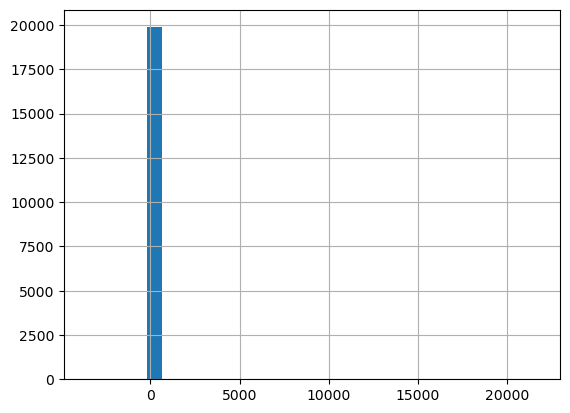

In [736]:
import scipy.stats as stats

# Rozkład różnic per SKU
straty_sku = df_rem_compare.groupby('SKU')['roznica'].sum()

# 1. Czy rozkład jest normalny?
stat, p = stats.shapiro(straty_sku)
print(f"Shapiro-Wilk: stat={stat:.3f}, p={p:.3f}")
print("Rozkład normalny" if p > 0.05 else "Rozkład NIE jest normalny")

# 2. Czy średnia strat różni się istotnie od 0?
t_stat, p_val = stats.ttest_1samp(straty_sku, popmean=0)
print(f"\nt-test: stat={t_stat:.3f}, p={p_val:.3f}")
print("Straty LOSOWE (brak systematycznego błędu)" if p_val > 0.05 
      else "Straty SYSTEMATYCZNE (nie są losowe)")

# 3. Histogram
straty_sku.hist(bins=30)

In [737]:
# Sprawdź co jest tym outlierem
print(straty_sku.sort_values().head(10))
print(straty_sku.sort_values().tail(10))
print(straty_sku.describe())

SKU
68      -3565.80
49811   -1731.87
49629   -1216.21
49631   -1118.37
86      -1096.00
49624   -1030.72
50007    -871.00
50069    -735.00
49637    -690.69
139      -671.00
Name: roznica, dtype: float64
SKU
55353     753.00
55393     765.00
77513     787.00
77531     887.00
55352    1013.00
17619    1465.00
18654    1517.00
54316    2902.98
38960    4065.00
18674   21698.00
Name: roznica, dtype: float64
count   19920.00
mean        5.97
std       165.23
min     -3565.80
25%         0.00
50%         0.00
75%         4.00
max     21698.00
Name: roznica, dtype: float64


Usunięto 33 outlierów


<Axes: >

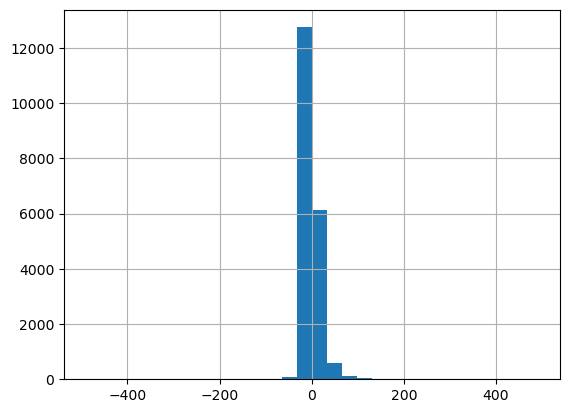

In [738]:
# Odetnij ekstrema np. poza 3 odchyleniami standardowymi
mean = straty_sku.mean()
std = straty_sku.std()

straty_bez_outlierow = straty_sku[
    (straty_sku > mean - 3*std) & 
    (straty_sku < mean + 3*std)
]

print(f"Usunięto {len(straty_sku) - len(straty_bez_outlierow)} outlierów")
straty_bez_outlierow.hist(bins=30)

In [739]:
# Czy te same SKU tracą przy każdym remanencie?
df_rem_compare.pivot_table(
    index='SKU', 
    columns='data_rem', 
    values='roznica'
).head(20)

data_rem,2023-01-02,2023-01-04,2023-01-05,2023-01-09,2023-02-09,2023-02-10,2023-02-19,2023-02-20,2023-02-21,2023-02-23,...,2025-11-17,2025-11-18,2025-11-21,2025-11-24,2025-11-27,2025-12-01,2025-12-08,2025-12-10,2025-12-11,2025-12-30
SKU,,,,,,,,,,,,,,,,,,,,,
5,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,-1.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


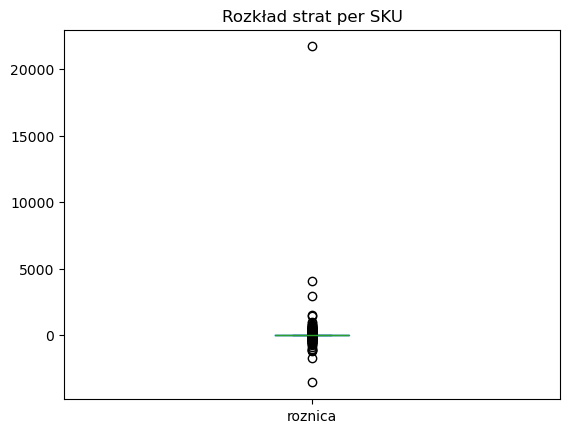

In [740]:
import matplotlib.pyplot as plt
straty_sku.plot.box()
plt.title('Rozkład strat per SKU')
plt.show()

SKU
18674   21698.00
38960    4065.00
54316    2902.98
18654    1517.00
17619    1465.00
Name: roznica, dtype: float64
              Data  TypDok                  NrDok  IloscPlus  IloscMinus
3190699 2023-01-01      14                BO/23/1  -11346.00        0.00
3210923 2023-01-01      14                BO/23/2       0.00        0.00
2241    2023-01-02      21     DF/PAR/230102/38/1       0.00       10.00
4489    2023-01-02      21    DF/PAR/230102/469/2       0.00        1.00
4474    2023-01-02      21    DF/PAR/230102/466/2       1.00        0.00
...            ...     ...                    ...        ...         ...
4155808 2025-12-31      21  DF/PAR/251231/15858/2       1.00        0.00
4155418 2025-12-31      21  DF/PAR/251231/15802/2       1.00        0.00
4154095 2025-12-31       1            OPAK/D/25/1      20.00        0.00
4157243 2025-12-31      21   DF/PAR/251231/6267/1       1.00        0.00
4158736 2025-12-31      21  DF/PAR/251231/16273/2       1.00        0.00

[112

<Axes: >

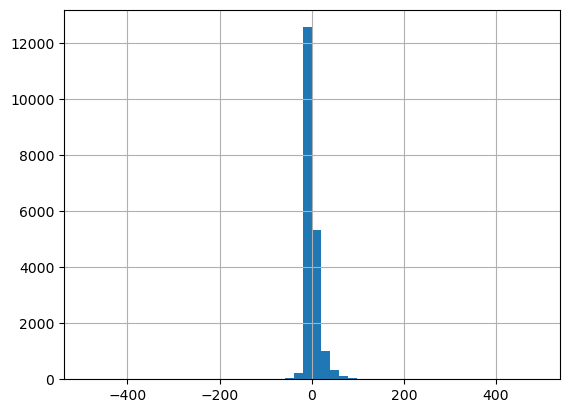

In [741]:
# 1. Znajdź ten outlier +22000
print(straty_sku.sort_values(ascending=False).head(5))

# 2. Sprawdź czy to błąd danych
sku_outlier = straty_sku.idxmax()
print(df[df['SKU'] == sku_outlier][
    ['Data', 'TypDok', 'NrDok', 'IloscPlus', 'IloscMinus']
].sort_values('Data'))

# 3. Histogram bez outlierów (zakres -500 do +500)
straty_sku[straty_sku.between(-500, 500)].hist(bins=50)

In [742]:
roznica_col = df_rem_compare['roznica']

print(f"Liczba SKU z różnicą = 0:     {(roznica_col == 0).sum()}")
print(f"Liczba SKU z niedoborem (<0):  {(roznica_col < 0).sum()}")
print(f"Liczba SKU z nadwyżką (>0):    {(roznica_col > 0).sum()}")
print()
print(f"Średnia strata:  {roznica_col[roznica_col < 0].mean():.1f}")
print(f"Mediana straty:  {roznica_col[roznica_col < 0].median():.1f}")
print(f"Łączny niedobór: {roznica_col[roznica_col < 0].sum():.0f} szt")
print(f"Łączna nadwyżka: {roznica_col[roznica_col > 0].sum():.0f} szt")

Liczba SKU z różnicą = 0:     34978
Liczba SKU z niedoborem (<0):  6361
Liczba SKU z nadwyżką (>0):    12667

Średnia strata:  -10.4
Mediana straty:  -4.0
Łączny niedobór: -66144 szt
Łączna nadwyżka: 185135 szt


In [743]:
# SKU które ZAWSZE mają niedobór
zawsze_niedobor = (
    df_rem_compare
    .groupby('SKU')
    .apply(lambda x: (x['roznica'] < 0).all())
)
print(f"SKU zawsze na minusie: {zawsze_niedobor.sum()}")

# SKU które ZAWSZE mają nadwyżkę  
zawsze_nadwyzka = (
    df_rem_compare
    .groupby('SKU')
    .apply(lambda x: (x['roznica'] > 0).all())
)
print(f"SKU zawsze na plusie: {zawsze_nadwyzka.sum()}")

SKU zawsze na minusie: 620
SKU zawsze na plusie: 891


## które SKU generują 80% obrotu

In [744]:
# Sprzedaż per SKU (tylko TypDok 21 i 59)
sprzedaz_sku = (
    df[df['TypDok'].isin([21])]
    .groupby(['SKU', 'Nazwa_towar'])
    .agg(
        wolumen=('IloscPlus', 'sum'),
        wartosc=('Wartosc', 'sum')
    )
    .reset_index()
    .sort_values('wartosc', ascending=False)
)

# Udział skumulowany
sprzedaz_sku['udzial_proc'] = (
    sprzedaz_sku['wartosc'] / sprzedaz_sku['wartosc'].sum() * 100
)
sprzedaz_sku['udzial_kum'] = sprzedaz_sku['udzial_proc'].cumsum()

# Segment Pareto
sprzedaz_sku['pareto'] = sprzedaz_sku['udzial_kum'].apply(
    lambda x: 'A (top 80%)' if x <= 80 
    else 'B (80-95%)' if x <= 95 
    else 'C (ogon)'
)

print(sprzedaz_sku['pareto'].value_counts())
print()
print(f"Łączna wartość sprzedaży: {sprzedaz_sku['wartosc'].sum():,.0f}")
display(sprzedaz_sku.head(20))

pareto
C (ogon)       6995
B (80-95%)     3177
A (top 80%)    2827
Name: count, dtype: int64

Łączna wartość sprzedaży: 17,885,160


,SKU,Nazwa_towar,wolumen,wartosc,udzial_proc,udzial_kum,pareto
4480,49624,BANAN /KG,18376.67,110389.56,0.62,0.62,A (top 80%)
17,75,PIECZYWO MIX,29969.00,100234.80,0.56,1.18,A (top 80%)
821,4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,4022.00,92349.42,0.52,1.69,A (top 80%)
2171,11978,WÓDKA ŻOŁĄDKOWA DE LUX 40% 500ML STOCK,3466.00,79877.51,0.45,2.14,A (top 80%)
2609,15149,PAPIEROSY WINSTON BLUE SUPER LINE JTI,4954.00,72051.92,0.40,2.54,A (top 80%)
2951,17470,SER PROMOCJA KG,2636.32,66562.93,0.37,2.92,A (top 80%)
34,96,BUŁKA KAJZERKA 50G MAREL,77712.00,62163.39,0.35,3.26,A (top 80%)
2608,15148,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,4050.00,59032.64,0.33,3.59,A (top 80%)
2313,13117,PAPIEROSY RGD PINK SSL 20SZT PHILIP MORRIS,4235.00,58871.16,0.33,3.92,A (top 80%)
7287,55191,MASŁO EKSTR A 83% 200G SPAR,8478.00,56892.55,0.32,4.24,A (top 80%)


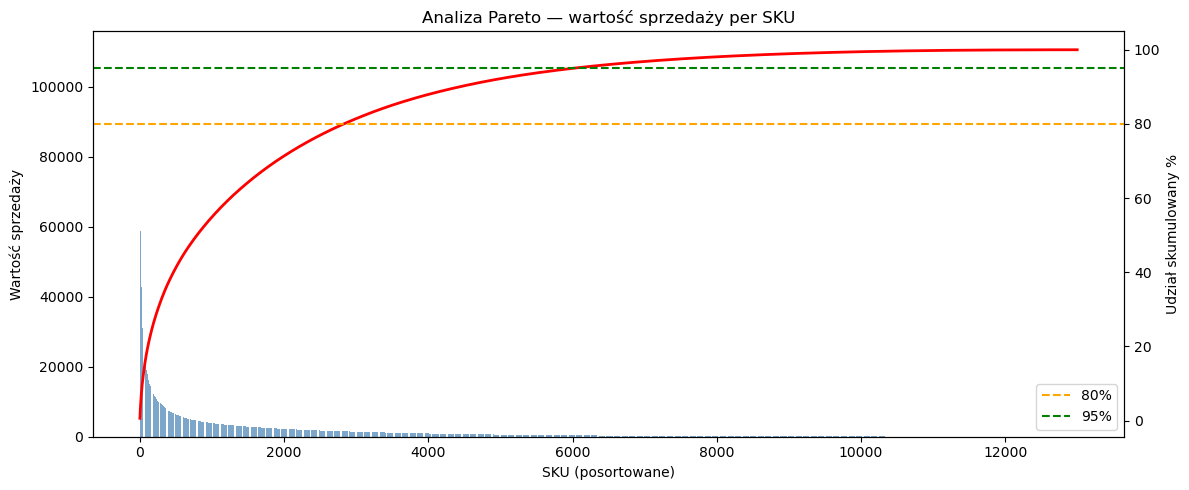

In [745]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))

# Słupki wartości
ax1.bar(range(len(sprzedaz_sku)), sprzedaz_sku['wartosc'], color='steelblue', alpha=0.7)
ax1.set_xlabel('SKU (posortowane)')
ax1.set_ylabel('Wartość sprzedaży')

# Linia kumulatywna
ax2 = ax1.twinx()
ax2.plot(range(len(sprzedaz_sku)), sprzedaz_sku['udzial_kum'], color='red', linewidth=2)
ax2.axhline(y=80, color='orange', linestyle='--', label='80%')
ax2.axhline(y=95, color='green', linestyle='--', label='95%')
ax2.set_ylabel('Udział skumulowany %')
ax2.legend()

plt.title('Analiza Pareto — wartość sprzedaży per SKU')
plt.tight_layout()
plt.show()

### Ile % SKU to segment A:

In [746]:
total_sku = len(sprzedaz_sku)
sku_A = (sprzedaz_sku['pareto'] == 'A (top 80%)').sum()
print(f"Segment A: {sku_A} SKU = {sku_A/total_sku*100:.1f}% wszystkich SKU generuje 80% obrotu")
print(f"Segment C: {6977} SKU = {6977/total_sku*100:.1f}% wszystkich SKU generuje tylko 5% obrotu")

Segment A: 2827 SKU = 21.7% wszystkich SKU generuje 80% obrotu
Segment C: 6977 SKU = 53.7% wszystkich SKU generuje tylko 5% obrotu


In [747]:
# Dodaj segment Pareto do głównego df
df = df.merge(
    sprzedaz_sku[['SKU', 'pareto']], 
    on='SKU', 
    how='left'
)
df['pareto'] = df['pareto'].fillna('D (brak sprzedaży)')
print(df['pareto'].value_counts())

pareto
A (top 80%)           3056985
B (80-95%)             742191
C (ogon)               277517
D (brak sprzedaży)      55924
Name: count, dtype: int64


In [748]:
# Czy produkty z ogona mają większe straty?
straty_pareto = (
    df_rem_compare
    .merge(sprzedaz_sku[['SKU', 'pareto']], on='SKU', how='left')
    .groupby('pareto')['roznica']
    .agg(['mean', 'sum', 'count'])
    .round(1)
)
print(straty_pareto)

             mean      sum  count
pareto                           
A (top 80%)  5.80 56619.10   9810
B (80-95%)   5.00 41950.40   8342
C (ogon)     1.80 22509.00  12569


### Które produkty sprzedają się najlepiej


In [749]:
# Top 20 produktów po wartości sprzedaży
print("=== TOP 20 po wartości ===")
display(
    sprzedaz_sku[['Nazwa_towar', 'wartosc', 'wolumen', 'udzial_proc']].sort_values('wartosc', ascending=False)
    .head(20)
)

=== TOP 20 po wartości ===


,Nazwa_towar,wartosc,wolumen,udzial_proc
4480,BANAN /KG,110389.56,18376.67,0.62
17,PIECZYWO MIX,100234.80,29969.00,0.56
821,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,92349.42,4022.00,0.52
2171,WÓDKA ŻOŁĄDKOWA DE LUX 40% 500ML STOCK,79877.51,3466.00,0.45
2609,PAPIEROSY WINSTON BLUE SUPER LINE JTI,72051.92,4954.00,0.40
2951,SER PROMOCJA KG,66562.93,2636.32,0.37
34,BUŁKA KAJZERKA 50G MAREL,62163.39,77712.00,0.35
2608,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,59032.64,4050.00,0.33
2313,PAPIEROSY RGD PINK SSL 20SZT PHILIP MORRIS,58871.16,4235.00,0.33
7287,MASŁO EKSTR A 83% 200G SPAR,56892.55,8478.00,0.32


In [750]:
# Top 20 po wolumenie (ilości sztuk)
print("=== TOP 20 po wolumenie (sztuki) ===")
display(
    sprzedaz_sku[['Nazwa_towar', 'wolumen', 'wartosc']]
    .sort_values('wartosc', ascending=False)
    .head(20)
)

=== TOP 20 po wolumenie (sztuki) ===


,Nazwa_towar,wolumen,wartosc
4480,BANAN /KG,18376.67,110389.56
17,PIECZYWO MIX,29969.00,100234.80
821,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,4022.00,92349.42
2171,WÓDKA ŻOŁĄDKOWA DE LUX 40% 500ML STOCK,3466.00,79877.51
2609,PAPIEROSY WINSTON BLUE SUPER LINE JTI,4954.00,72051.92
2951,SER PROMOCJA KG,2636.32,66562.93
34,BUŁKA KAJZERKA 50G MAREL,77712.00,62163.39
2608,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,4050.00,59032.64
2313,PAPIEROSY RGD PINK SSL 20SZT PHILIP MORRIS,4235.00,58871.16
7287,MASŁO EKSTR A 83% 200G SPAR,8478.00,56892.55


## Ilosc ZAM i PZ

In [751]:
print("=== ZAM (TypDok=50) ===")
print(df[df['TypDok']==50].groupby('Nazwa_towar')['IloscPlus'].agg(['sum','count']).sort_values('sum', ascending=False).head(20))


=== ZAM (TypDok=50) ===
                                                   sum  count
Nazwa_towar                                                  
BILET 4.40                                    15010.00    152
WODA MIN N/GAZ MUSZYNIANKA 1,5L MUSZYNIANKA   12849.00    266
ŚMIETANA KUB 18% 200G PIĄTNICA                10860.00    382
BILET 2,2                                      9510.00     97
SEREK WIEJSKI LEKKI 150G PIĄTNICA              9192.00    389
SEREK WIEJSKI NATURALNY 200G PIĄTNICA          8784.00    392
MASŁO EKSTR A 83% 200G SPAR                    8280.00    172
SEREK WIEJSKI ZE SZCZYPIORKIEM 200G ŁÓDŹ       7380.00    154
LODY BAMBINO W CZEKOLADZIE ŁÓDŹ                7301.00    126
MLEKO ŚWIEŻE BUT ŁACIATE 3,2% 1L MLEKPOL       7010.00    398
MLEKO ŚWIEŻE BUT ŁACIATE 2% 1L MLEKPOL         6672.00    389
WODA GAZ ŻYWIEC ZDRÓJ 1,5L                     6535.00    247
JOGURT PRIMO NATURALNY B/L 180G ZOTT           6368.00    304
JOGURT NATURALNY PRIMO 180G ZOTT              

In [752]:

print("\n=== PZ (TypDok=2) ===")
print(df[df['TypDok']==2].groupby('Nazwa_towar')['IloscPlus'].agg(['sum','count']).sort_values('sum', ascending=False).head(20))



=== PZ (TypDok=2) ===
                                                 sum  count
Nazwa_towar                                                
BUŁKA KAJZERKA 50G MAREL                    77766.00    169
TORBA RECYKLING SPAR 30X55 1SZT             43500.00     70
Bulka poznanska 0.1                         38059.00    163
PIECZYWO MIX                                30741.00   2163
BUŁKA KAJZERKA PRECELEK                     21064.00    165
BANAN /KG                                   19707.00    422
BUŁKA ZIARNO MIX                            18482.00   1102
Rogal maslany nowy POLPAIN                  17654.00    325
Chleb mieszany krojony 0.6kg    PRECELEK    13895.00    337
BILET 4.40                                  13400.00    134
WODA MIN N/GAZ MUSZYNIANKA 1,5L MUSZYNIANKA 13386.00    274
ŚMIETANA KUB 18% 200G PIĄTNICA              10748.00    375
PĄCZEK SZT                                   9759.00     71
SEREK WIEJSKI LEKKI 150G PIĄTNICA            9231.00    392
BILET 2,2        

In [753]:

print("\n=== Podsumowanie ===")
print(f"Liczba ZAM: {(df['TypDok']==50).sum()}")
print(f"Liczba PZ:  {(df['TypDok']==2).sum()}")
print(f"Suma ZAM:   {df[df['TypDok']==50]['IloscPlus'].sum():.0f} szt")
print(f"Suma PZ:    {df[df['TypDok']==2]['IloscPlus'].sum():.0f} szt")


=== Podsumowanie ===
Liczba ZAM: 205544
Liczba PZ:  255213
Suma ZAM:   2558015 szt
Suma PZ:    3701857 szt


## Na czym się najwięcęj zarabia

In [754]:
print("=== TOP 20 po marży łącznej ===")
display(
    df[df['TypDok'].isin([21])]
    .groupby('Nazwa_towar')['Marza']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)


=== TOP 20 po marży łącznej ===


Nazwa_towar
TORBA RECYKLING SPAR 30X55 1SZT               8796.80
BANAN /KG                                     5661.20
BUŁKA KAJZERKA 50G MAREL                      4910.00
PIECZYWO MIX                                  4090.40
CYTRYNY TURCJA KG                             3122.28
Bulka poznanska 0.1                           3061.00
Chleb mieszany krojony 0.6kg    PRECELEK      2395.80
Rogal maslany nowy POLPAIN                    2266.00
BUŁKA ZIARNO MIX                              2153.28
ŚMIETANA KUB 18% 200G PIĄTNICA                2120.40
CHLEB MIESZANY KROJONY 500G MAREL             2076.75
SER PROMOCJA KG                               2076.40
JABŁKA POLSKA KG                              1944.80
ZUPA STAND WINIARY BARSZCZ BIAŁY 66G NESTLE   1800.00
MLEKO ŚWIEŻE BUT ŁACIATE 3,2% 1L MLEKPOL      1724.50
MANDARYNKA 1KG LUZ HISZPANIA                  1708.60
CHLEB MIESZANY KROJONY 250G MAREL             1657.00
WODA MIN N/GAZ MUSZYNIANKA 1,5L MUSZYNIANKA   1643.60
SEREK WIEJSKI LE

In [755]:


print("=== TOP 20 po % marży ===")
marza_proc = (
    df[df['TypDok'].isin([21])]
    .groupby('Nazwa_towar')
    .agg(
        marza=('Marza', 'sum'),
        wartosc=('Wartosc', 'sum')
    )
)
marza_proc['marza_proc'] = (marza_proc['marza'] / marza_proc['wartosc'] * 100).round(1)
display(marza_proc.sort_values('marza_proc', ascending=False).head(20))

=== TOP 20 po % marży ===


,marza,wartosc,marza_proc
Nazwa_towar,,,
Reklamówka biodegradowalna,98.00,42.90,228.50
KUBEK JEDNORAZOWY,0.40,0.49,82.00
GUMA CENTER SHOCK MONSTER 4G VAN MELE,26.75,64.45,41.50
Czapeczki 1 szt,0.30,0.80,37.30
TORBA RECYKLING SPAR 30X55 1SZT,8796.80,25112.68,35.00
REKLAMÓWKA SPAR średnia,23.40,70.57,33.20
"REKLAMÓWKA MIKOŁAJ, CHOINKA",37.20,114.39,32.50
GUMA CENTER SHOCK JABŁKO 4G VAN MELE,20.75,64.29,32.30
WYKAŁACZKI ZAPAS 100SZT PIKNIK,5.40,17.41,31.00


In [756]:
df['marza_zl'] = df['Wartosc'] * df['Marza'] / 100

In [757]:
df.head(10)

,DokId,Kolejnosc,NrPozycji,SKU,TypPoz,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,...,DzienTygodnia,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia,pareto,marza_zl
0,1165932,1,1,24787,1,1.00,0.00,4.86,4.86,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
1,1165932,2,2,18670,1,2.00,0.00,2.96,5.92,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
2,1165932,3,3,18653,1,7.00,0.00,2.25,15.75,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,B (80-95%),0.00
3,1165932,4,4,18668,1,9.00,0.00,2.10,18.90,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,A (top 80%),0.00
4,1165932,5,5,22303,1,2.00,0.00,5.62,11.24,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
5,1165932,6,6,36367,1,1.00,0.00,2.46,2.46,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
6,1165932,7,7,20801,1,2.00,0.00,2.74,5.48,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,B (80-95%),0.00
7,1165932,8,8,20958,1,2.00,0.00,3.17,6.34,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
8,1165932,9,9,18656,1,2.00,0.00,4.92,9.84,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,B (80-95%),0.00
9,1165932,10,10,55322,1,10.00,0.00,4.93,49.30,2023-01-02,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,A (top 80%),0.00


In [758]:
# artykuly 2023
df_2023_1 = df[
    (df['Rok'] == 2023) & 
    (df['Miesiac'] == 1)
].copy()
df_2023_1.to_csv('dane/artykuly_2023_1.csv',index=False)
# artykuly 2024
# df_2024 = df[df['Rok'] == 2024].copy()
# df_2024.to_csv('dane_all_product/artykuly_2024.csv',index=False)
# #artykuly 2025
# df_2025 = df[df['Rok'] == 2025].copy()
# df_2025.to_csv('dane_all_product/artykuly_2025.csv',index=False)

In [759]:
df.sample(5)

,DokId,Kolejnosc,NrPozycji,SKU,TypPoz,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,...,DzienTygodnia,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia,pareto,marza_zl
1979127,1686006,7,7,49811,4,0.55,0.00,6.66,3.65,2024-06-04,...,1,False,-0.00,-0.00,Wtorek,False,False,Wtorek,A (top 80%),0.01
3135433,1974588,9,9,6438,4,1.00,0.00,3.00,3.00,2025-04-04,...,4,False,-0.00,-0.00,Piątek,False,False,Piątek,A (top 80%),0.01
449182,1275703,3,3,7983,4,1.00,0.00,7.99,7.99,2023-04-27,...,3,False,-0.00,-0.00,Czwartek,False,False,Czwartek,A (top 80%),0.02
724624,1343835,3,3,53946,4,1.00,0.00,2.99,2.99,2023-07-15,...,5,False,-0.00,-0.00,Sobota,False,False,Sobota,B (80-95%),0.01
3944224,2167755,6,6,50256,4,1.00,0.00,7.13,7.13,2025-11-08,...,5,False,-0.00,-0.00,Sobota,False,False,Sobota,A (top 80%),0.00


In [760]:
df.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'SKU', 'TypPoz', 'IloscPlus',
       'IloscMinus', 'CenaPoRab', 'Wartosc', 'Data', 'KolejnyWDniu', 'NrDok',
       'TypDok', 'Aktywny', 'NrKolejny', 'AsId', 'Nazwa_towar', 'Kod', 'Marza',
       'CenaDet', 'Nazwa_asort', 'Rok', 'Miesiac', 'RokMiesiac',
       'DzienTygodnia', 'czy_remanent', 'ilosc_netto', 'Ruch', 'nazwa_dnia',
       'dlugi_weekend', 'niedziela_handlowa', 'kategoria_dnia', 'pareto',
       'marza_zl'],
      dtype='str')

## Co najlepiej sprzedaje się w piątki

In [761]:
for i in range(1, 13):
    df_month = df[df['Miesiac'] == i].copy()
    piatki = df_month[(df_month['nazwa_dnia'] == 'Piątek')]
    top = piatki.groupby(['SKU', 'Nazwa_towar']).agg(
    wartosc=('Wartosc', 'sum'),
    ilosc=('ilosc_netto', 'sum')
).sort_values('wartosc', ascending=False)
    print(f"\n=== Miesiąc {i} - TOP Piątki ===")
    display(top.head(5))


=== Miesiąc 1 - TOP Piątki ===


,,wartosc,ilosc
SKU,Nazwa_towar,,
14957,CUKIER KRYSZTAŁ SWEET FAMILY 1KG NORDZUCKER,7222.36,450.00
49624,BANAN /KG,5570.46,646.21
11978,WÓDKA ŻOŁĄDKOWA DE LUX 40% 500ML STOCK,4282.49,150.00
17470,SER PROMOCJA KG,3982.38,71.52
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,3797.84,105.00



=== Miesiąc 2 - TOP Piątki ===


,,wartosc,ilosc
SKU,Nazwa_towar,,
50008,MANDARYNKA 1KG LUZ HISZPANIA,5362.02,611.87
49624,BANAN /KG,5243.39,663.01
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,4149.78,105.00
15149,PAPIEROSY WINSTON BLUE SUPER LINE JTI,4080.29,160.00
17470,SER PROMOCJA KG,3907.93,101.88



=== Miesiąc 3 - TOP Piątki ===


...

,,wartosc,ilosc
SKU,Nazwa_towar,,
15148,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,5163.39,180.00
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,4892.96,150.00
15149,PAPIEROSY WINSTON BLUE SUPER LINE JTI,4870.81,160.00
66340,PAPIEROSY L&M FIRST CUT ZIELONE SSL PM,4546.56,150.00
23551,BILET 4.40,4244.40,600.00



=== Miesiąc 11 - TOP Piątki ===


,,wartosc,ilosc
SKU,Nazwa_towar,,
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,5198.88,210.00
49624,BANAN /KG,4600.83,513.16
17470,SER PROMOCJA KG,4514.75,64.17
15149,PAPIEROSY WINSTON BLUE SUPER LINE JTI,4022.88,200.00
15148,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,4012.99,200.00



=== Miesiąc 12 - TOP Piątki ===


,,wartosc,ilosc
SKU,Nazwa_towar,,
49624,BANAN /KG,5000.98,735.72
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,4251.98,150.00
12108,"WÓDKA ŻUBR STRONG 37,5% 90ML STOCK",3984.21,448.00
17470,SER PROMOCJA KG,3890.81,86.63
55191,MASŁO EKSTR A 83% 200G SPAR,3257.35,350.00


In [762]:
for i in range(1, 13):
    df_month = df[df['Miesiac'] == i].copy()
    dlugi_weekend = df_month[(df_month['dlugi_weekend'] == True)]
    top = dlugi_weekend.groupby(['SKU', 'Nazwa_towar']).agg(
    wartosc=('Wartosc', 'sum'),
    ilosc=('ilosc_netto', 'sum')
).sort_values('wartosc', ascending=False)
    print(f"\n=== Miesiąc {i} - TOP Długi Weekend ===")
    display(top.head(5))


=== Miesiąc 1 - TOP Długi Weekend ===


,,wartosc,ilosc
SKU,Nazwa_towar,,



=== Miesiąc 2 - TOP Długi Weekend ===


,,wartosc,ilosc
SKU,Nazwa_towar,,



=== Miesiąc 3 - TOP Długi Weekend ===


...

,,wartosc,ilosc
SKU,Nazwa_towar,,



=== Miesiąc 11 - TOP Długi Weekend ===


,,wartosc,ilosc
SKU,Nazwa_towar,,



=== Miesiąc 12 - TOP Długi Weekend ===


,,wartosc,ilosc
SKU,Nazwa_towar,,


### Sprawdzam jak się sprzedają kategorie asortyment

In [763]:
len(list(df.AsId.unique()))

298

In [764]:
# Agregacja per kategoria
agg = df.groupby(['AsId', 'Nazwa_asort']).agg(
    wartosc=('Wartosc', 'sum'),
    
    ilosc_sku=('SKU', 'nunique'),
    transakcje=('DokId', 'nunique')   
).reset_index()


In [765]:
agg['wartosc_na_sku'] = (agg['wartosc'] / agg['ilosc_sku']).round(0)

In [766]:
# Klasyfikacja wg wartość
def klasyfikuj(val):
    if val == 0:   return 'ZERO - brak sprzedaży'
    if val < 0:    return 'UJEMNE - zwroty'
    if val < 500:  return 'MARGINALNE'
    return 'AKTYWNA'

In [767]:
agg['status'] = agg['wartosc'].apply(klasyfikuj)

In [768]:
# Podgląd kandydatów do usunięcia
zbedne = agg[agg['status'].isin(['ZERO - brak sprzedaży', 'MARGINALNE'])]
print(f"Kandydaci do usunięcia: {len(zbedne)} kategorii")
display(zbedne[['AsId', 'Nazwa_asort', 'wartosc', 'ilosc_sku', 'status']])


Kandydaci do usunięcia: 57 kategorii


,AsId,Nazwa_asort,wartosc,ilosc_sku,status
31,33.00,DODATKI SPOŻYWCZE,0.00,1,ZERO - brak sprzedaży
44,47.00,x DOŁADOWANIA,0.00,14,ZERO - brak sprzedaży
45,48.00,DOŁADOWANIA I STARTERY,0.00,2,ZERO - brak sprzedaży
48,51.00,PARAFARMACEUTYKI /farmaceutyki,20.93,2,MARGINALNE
50,53.00,ŚRODKI OPATRUNKOWE /farmaceutyki,216.50,15,MARGINALNE
51,54.00,x KOSMETYKI,405.87,30,MARGINALNE
53,56.00,BIO /kosmetyki,0.00,22,ZERO - brak sprzedaży
61,65.00,ZESTAWY I KOSMETYCZKI /kosmetyki,416.83,2,MARGINALNE
101,107.00,OWOCE I WARZYWA,0.00,2,ZERO - brak sprzedaży
120,126.00,"PIZZE, ZAPIEKANKI I CEBULAKI",124.00,4,MARGINALNE


In [769]:
# # Progi ilości transakcji
print(sku['transakcje'].describe())
print()
print(sku['transakcje'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

IndexError: invalid index to scalar variable.

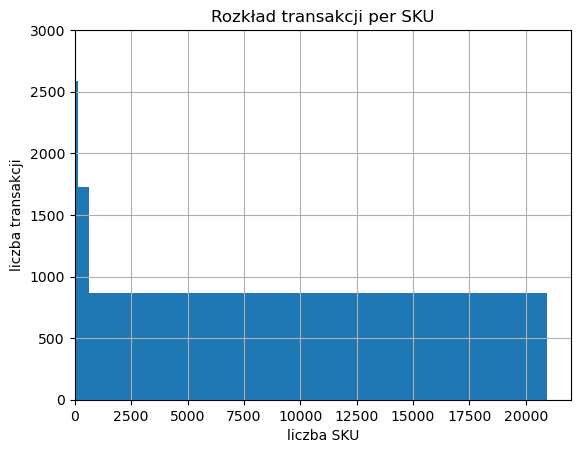

In [ ]:
sku['transakcje'].hist(bins=50, orientation='horizontal')
plt.ylabel('liczba transakcji')
plt.xlabel('liczba SKU')
plt.ylim(0, 3000)
plt.title('Rozkład transakcji per SKU')
plt.show()

In [ ]:
## Ilość transakcji na SKU
prog = 500
def klasyfikuj_tx(val):
    if val <100:    return 'D - brak'
    if (val >=100 and val < prog):    return 'C - sporadyczny'
    if (val>=prog and val<=1000):     return 'B - regularny'
    return 'A - popularny'

sku = df.groupby(['SKU', 'Nazwa_towar']).agg(
    transakcje=('DokId', 'nunique'),
    wartosc=('Wartosc', 'sum'),
    ilosc=('ilosc_netto', 'sum')
).reset_index()

sku['klasa_tx'] = sku['transakcje'].apply(klasyfikuj_tx)

print(sku['klasa_tx'].value_counts())

klasa_tx
D - brak           16188
C - sporadyczny     3769
B - regularny       1196
A - popularny        711
Name: count, dtype: int64


In [ ]:
# Klasyfikacja per kategoria AsId
prog = 500

def klasyfikuj_tx(val):
    if val < 100:                    return 'D - brak'
    if val >= 100 and val < prog:    return 'C - sporadyczny'
    if val >= prog:                  return 'B - regularny'
    return 'A - popularny'

asid = df.groupby(['AsId', 'Nazwa_asort']).agg(
    transakcje=('DokId', 'nunique'),
    wartosc=('Wartosc', 'sum'),
    ilosc_sku=('SKU', 'nunique')
).reset_index()

asid['klasa_tx'] = asid['transakcje'].apply(klasyfikuj_tx)

print(asid['klasa_tx'].value_counts())
print()
print(asid.sort_values('transakcje', ascending=True).to_string())

klasa_tx
B - regularny      191
D - brak            68
C - sporadyczny     39
Name: count, dtype: int64

      AsId                               Nazwa_asort  transakcje    wartosc  ilosc_sku         klasa_tx
281 338.00                                    VIRGIN           2      16.26          1         D - brak
278 334.00                                     HEYAH           4      99.93          5         D - brak
168 180.00                         INNE /przemysłowe           5       0.00          3         D - brak
45   48.00                    DOŁADOWANIA I STARTERY           5       0.00          2         D - brak
44   47.00                             x DOŁADOWANIA           5       0.00         14         D - brak
53   56.00                            BIO /kosmetyki           5       0.00         22         D - brak
159 170.00                    AGD I RTV /przemysłowe           5       0.00          2         D - brak
229 248.00                SMAKOSZ /dodatki spożywcze           

In [ ]:
for klasa in ['D - brak', 'C - sporadyczny', 'B - regularny']:
    print(f"\n=== {klasa} ===")
    print(asid[asid['klasa_tx'] == klasa][['AsId', 'Nazwa_asort', 'transakcje', 'wartosc']].to_string())


=== D - brak ===
      AsId                               Nazwa_asort  transakcje  wartosc
31   33.00                         DODATKI SPOŻYWCZE           8     0.00
44   47.00                             x DOŁADOWANIA           5     0.00
45   48.00                    DOŁADOWANIA I STARTERY           5     0.00
47   50.00                        LEKI /farmaceutyki          54   854.55
48   51.00            PARAFARMACEUTYKI /farmaceutyki           5    20.93
49   52.00                PREZERWATYWY /farmaceutyki           5    -1.04
50   53.00          ŚRODKI OPATRUNKOWE /farmaceutyki          28   216.50
51   54.00                               x KOSMETYKI           7   405.87
53   56.00                            BIO /kosmetyki           5     0.00
60   64.00                      DZIECIĘCE /kosmetyki          31   522.79
61   65.00          ZESTAWY I KOSMETYCZKI /kosmetyki           8   416.83
63   67.00                                GARMAŻERKA          47   532.05
64   68.00          